# 卷积神经网络

> **斯坦福 CS231n Lecture 5** | Image Classification with CNNs

## 本章导读

卷积神经网络 (CNN) 是计算机视觉的核心架构。本节从卷积运算的直觉出发，手算验证，然后从零实现卷积层和池化层，最后可视化 CNN 学习的特征图。

**学习目标：**
- 理解卷积运算的数学原理
- 掌握参数共享和局部连接的优势
- 从零实现 Conv2d 和 MaxPool2d
- 可视化 CNN 特征图

**参考来源：** [CS231n CNN Notes](https://cs231n.github.io/convolutional-networks/)

## 1. 卷积运算

### 卷积层的核心概念

- **局部连接**：每个神经元只看局部区域（感受野）
- **参数共享**：同一滤波器在整张图上滑动
- **平移等变性**：特征检测不依赖位置

### 数学定义

对于输入 $X \in \mathbb{R}^{C_{in} \times H \times W}$，卷积核 $K \in \mathbb{R}^{C_{out} \times C_{in} \times K_H \times K_W}$：

$$\text{out}[c_{out}, i, j] = \sum_{c_{in}} \sum_{di} \sum_{dj} X[c_{in}, i+di, j+dj] \cdot K[c_{out}, c_{in}, di, dj]$$

### 输出尺寸计算
$$H_{out} = \frac{H_{in} + 2P - K_H}{S} + 1$$

其中 $P$ 是 padding，$S$ 是 stride。

## 2. 手算验证

### 示例：单通道 3×3 输入，2×2 卷积核，无 padding，stride=1

输入：
$$
X = \begin{bmatrix} 1 & 2 & 0 \\ 0 & 1 & 1 \\ 3 & 0 & 2 \end{bmatrix}
$$

卷积核：
$$
K = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
$$

输出（2×2）：
- $\text{out}[0,0] = 1 \times 1 + 2 \times 0 + 0 \times 0 + 1 \times 1 = 2$
- $\text{out}[0,1] = 2 \times 1 + 0 \times 0 + 1 \times 0 + 1 \times 1 = 3$
- $\text{out}[1,0] = 0 \times 1 + 1 \times 0 + 3 \times 0 + 0 \times 1 = 0$
- $\text{out}[1,1] = 1 \times 1 + 1 \times 0 + 0 \times 0 + 2 \times 1 = 3$

$$\text{out} = \begin{bmatrix} 2 & 3 \\ 0 & 3 \end{bmatrix}$$

In [4]:
# 从零实现卷积层（朴素版本）
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

def conv2d_naive(x, kernel, stride=1, padding=0):
    """朴素卷积实现
    x: (C_in, H, W)
    kernel: (C_out, C_in, KH, KW)
    """
    C_in, H, W = x.shape
    C_out, _, KH, KW = kernel.shape
    
    if padding > 0:
        x = np.pad(x, ((0,0), (padding, padding), (padding, padding)), mode='constant')
        H, W = H + 2*padding, W + 2*padding
    
    H_out = (H - KH) // stride + 1
    W_out = (W - KW) // stride + 1
    out = np.zeros((C_out, H_out, W_out))
    
    for co in range(C_out):
        for i in range(H_out):
            for j in range(W_out):
                h_start = i * stride
                w_start = j * stride
                receptive = x[:, h_start:h_start+KH, w_start:w_start+KW]
                out[co, i, j] = np.sum(receptive * kernel[co])
    return out

# 验证手算结果
X = np.array([[[1, 2, 0], [0, 1, 1], [3, 0, 2]]], dtype=float)
K = np.array([[[[1, 0], [0, 1]]]], dtype=float)
out = conv2d_naive(X, K, stride=1, padding=0)
print(f"卷积输出:\n{out[0]}")
print(f"期望输出: [[2, 3], [0, 3]]")
assert np.allclose(out[0], [[2, 3], [0, 3]]), "与手算结果不一致!"
print("验证通过!")

卷积输出:
[[2. 3.]
 [0. 3.]]
期望输出: [[2, 3], [0, 3]]
验证通过!


In [5]:
# 从零实现 MaxPool 层
def maxpool2d_naive(x, pool_size=2, stride=2):
    """朴素最大池化
    x: (C, H, W)
    """
    C, H, W = x.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    out = np.zeros((C, H_out, W_out))
    
    for c in range(C):
        for i in range(H_out):
            for j in range(W_out):
                h_start = i * stride
                w_start = j * stride
                out[c, i, j] = np.max(x[c, h_start:h_start+pool_size, w_start:w_start+pool_size])
    return out

# 测试池化
x_test = np.array([[[1, 2, 3, 4],
                     [5, 6, 7, 8],
                     [9, 10, 11, 12],
                     [13, 14, 15, 16]]], dtype=float)
pooled = maxpool2d_naive(x_test)
print(f"池化输出:\n{pooled[0]}")
assert pooled[0, 0, 0] == 6, "左上角应为6"
assert pooled[0, 0, 1] == 8, "右上角应为8"
print("池化验证通过!")

池化输出:
[[ 6.  8.]
 [14. 16.]]
池化验证通过!


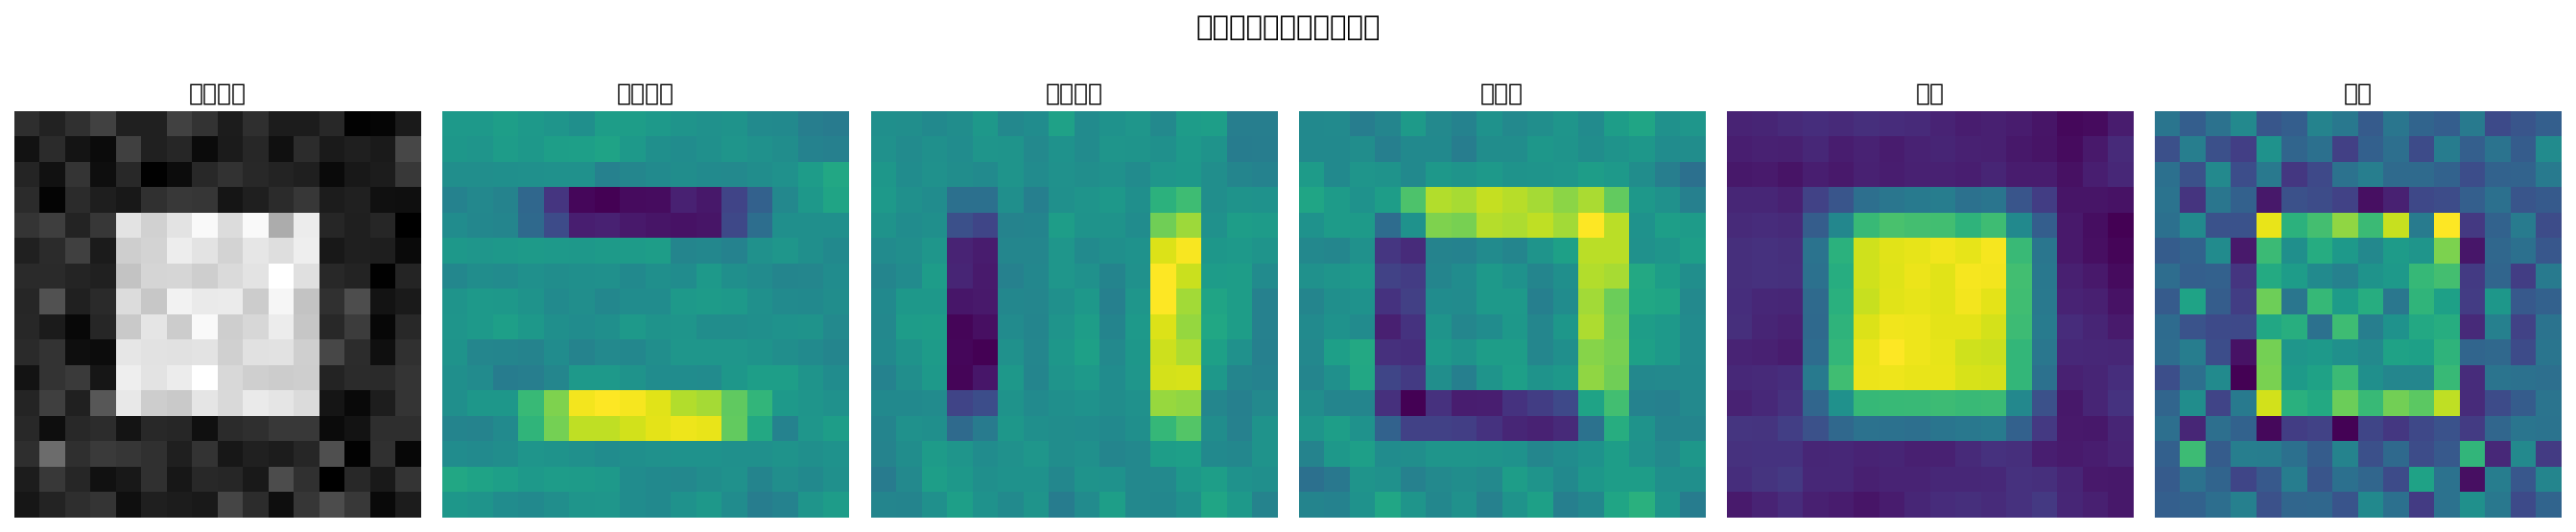

In [6]:
# 可视化卷积特征图
# 使用常见滤波器
from scipy import ndimage

# 生成一个模拟图像
image = np.zeros((16, 16))
image[4:12, 4:12] = 1  # 中心方块
image += np.random.randn(16, 16) * 0.1

# 定义滤波器
filters = {
    '水平边缘': np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]),
    '垂直边缘': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]),
    '对角线': np.array([[0, 1, 1], [-1, 0, 1], [-1, -1, 0]]),
    '模糊': np.ones((3, 3)) / 9,
    '锐化': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
}

fig, axes = plt.subplots(1, len(filters) + 1, figsize=(18, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('原始图像')
axes[0].axis('off')

for i, (name, kernel) in enumerate(filters.items()):
    result = ndimage.convolve(image, kernel)
    axes[i+1].imshow(result, cmap='viridis')
    axes[i+1].set_title(name)
    axes[i+1].axis('off')

plt.suptitle('卷积滤波器特征图可视化', fontsize=14)
plt.tight_layout()
plt.savefig('lecture-05-cnn/feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 实验观察：CNN 的层次化特征

CNN 的核心优势在于自动学习层次化特征：
- **浅层**：边缘、颜色、纹理
- **中层**：部件、模式（眼睛、车轮）
- **深层**：物体、场景

这种层次化表示是通过反向传播自动学习的，不需要人工设计特征。

### 参数量比较

| 层类型 | 参数量 | 感受野 |
|-------|--------|--------|
| 全连接 (1000→1000) | 1,000,000 | 全局 |
| 卷积 (3×3, 64通道) | 576 + 64 | 局部 |
| 参数比 | ~1700:1 | 局部→全局 |

参数共享使得 CNN 在图像任务上远比 MLP 高效。

## 作业

### 作业 1：计算输出尺寸

给定输入 $32 \times 32 \times 3$，卷积核 $5 \times 5 \times 3 \times 10$，stride=2，padding=2，输出尺寸是多少？

In [9]:
# 作业 1：验证输出尺寸
def conv_output_size(H_in, W_in, K, S, P):
    """计算卷积输出尺寸"""
    H_out = None  # 在此实现
    W_out = None
    return H_out, W_out

H, W = conv_output_size(32, 32, 5, 2, 2)
assert H == 16 and W == 16, f"期望 (16, 16), 得到 ({H}, {W})"
print("作业 1 通过!")

AssertionError: 期望 (16, 16), 得到 (None, None)

## 参考文献

1. **CS231n Convolutional Networks Notes** - [cs231n.github.io/convolutional-networks](https://cs231n.github.io/convolutional-networks/)
2. **Deep Learning Book Ch. 9** - Goodfellow et al., 2016. [Chapter 9](http://www.deeplearningbook.org/contents/convnets.html)
3. **Understanding CNNs** - Zeiler & Fergus, 2014. [ECCV 2014](https://arxiv.org/abs/1411.2524)

---

> 本节内容参考 [Stanford CS231n Lecture 5](https://cs231n.stanford.edu/)